# Marathon Performance Analysis

## Objective
Analyze marathon performance data to evaluate pacing strategy, identify fatigue points, and determine whether terrain or endurance was the primary driver of performance decline.

## Tools Used
- Python (Pandas, Matplotlib)
- Google Colab

In [12]:
from google.colab import files
uploaded = files.upload()

Saving Marathon.csv to Marathon (1).csv


In [14]:
import pandas as pd

df = pd.read_csv('Marathon.csv')
df.head()

,Mile,Pace,Gap,Elevation
0,1.0,10:23,10:18,16
1,2.0,9:47,9:42,7
2,3.0,9:58,9:54,5
3,4.0,10:09,9:52,37
4,5.0,10:06,9:26,107


In [15]:
def pace_to_min(pace):
    m, s = str(pace).split(':')
    return int(m) + int(s)/60

df['pace_min'] = df['Pace'].apply(pace_to_min)
df['gap_min'] = df['Gap'].apply(pace_to_min)

df.head()

,Mile,Pace,Gap,Elevation,pace_min,gap_min
0,1.0,10:23,10:18,16,10.383333,10.300000
1,2.0,9:47,9:42,7,9.783333,9.700000
2,3.0,9:58,9:54,5,9.966667,9.900000
3,4.0,10:09,9:52,37,10.150000,9.866667
4,5.0,10:06,9:26,107,10.100000,9.433333


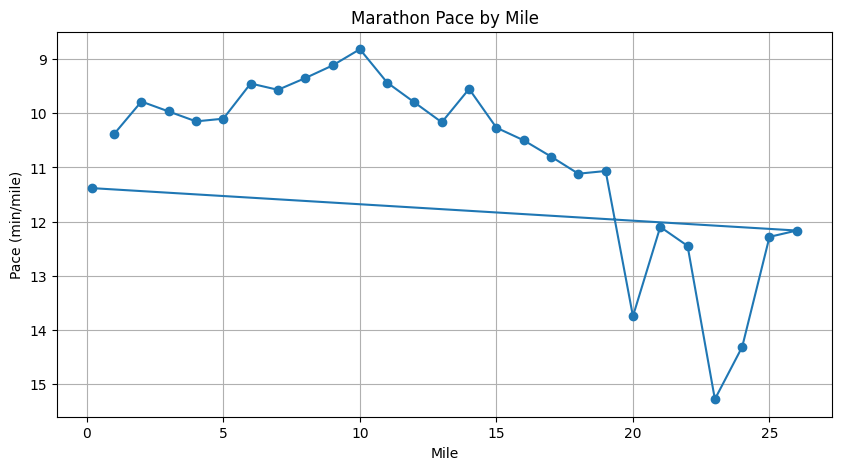

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df['Mile'], df['pace_min'], marker='o')
plt.title('Marathon Pace by Mile')
plt.xlabel('Mile')
plt.ylabel('Pace (min/mile)')
plt.gca().invert_yaxis()
plt.grid(True)
plt.show()

In [17]:
first_half = df[df['Mile'] <= 13]['pace_min'].mean()
second_half = df[df['Mile'] > 13]['pace_min'].mean()

print("First Half Avg:", round(first_half, 2))
print("Second Half Avg:", round(second_half, 2))
print("Difference:", round(second_half - first_half, 2), "min/mile")

First Half Avg: 9.82
Second Half Avg: 11.97
Difference: 2.15 min/mile


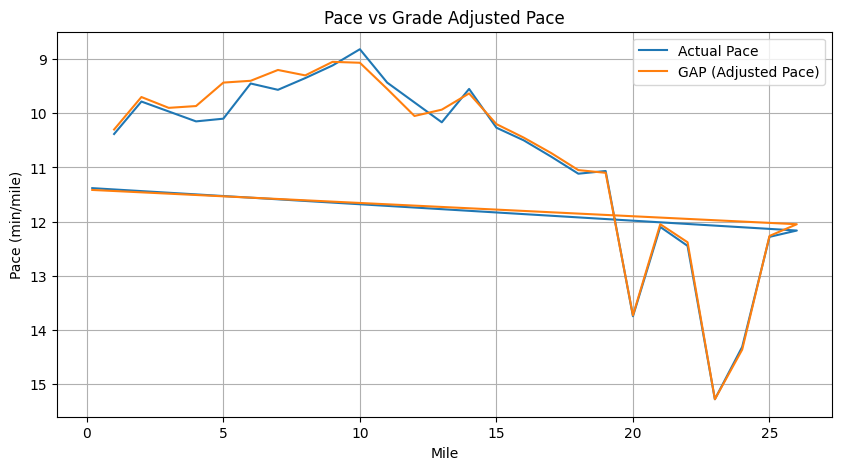

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(df['Mile'], df['pace_min'], label='Actual Pace')
plt.plot(df['Mile'], df['gap_min'], label='GAP (Adjusted Pace)')

plt.title('Pace vs Grade Adjusted Pace')
plt.xlabel('Mile')
plt.ylabel('Pace (min/mile)')
plt.gca().invert_yaxis()
plt.legend()
plt.grid(True)

plt.show()

**Marathon Performance Analysis – Findings**
- I averaged a 9.82 min/mile pace in the first half of the race, but slowed to 11.97 min/mile in the second half. A drop of about 2.15 minutes per mile

- My pace began to decline around mile 17–18, with a clear breakdown after mile 20

- When comparing actual pace to grade-adjusted pace (GAP), both declined in the later miles, indicating the slowdown was driven by fatigue rather than elevation

- Overall, the data suggests I started at a pace that wasn’t sustainable, which led to a significant drop in performance late in the race

**Key Takeaway:**

Starting too aggressively led to a measurable performance decline later in the race, highlighting the importance of pacing strategy in endurance events.